In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


##*step*(1) Machine Learning Models
-----------------------
*Weeks 1–4 | 35 pts*


Here we load and print the first 5 rows

In [6]:
df = pd.read_csv('train.csv')
print(df.head())

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare
0            1         0       3  22.0      1      0   7.2500
1            2         1       1  38.0      1      0  71.2833
2            3         1       3  26.0      0      0   7.9250
3            4         1       1  35.0      1      0  53.1000
4            5         0       3  35.0      0      0   8.0500


Look at the shape

In [7]:
df.shape
# (891,7)

(891, 7)

Print the missing val

In [8]:
miss_d=df.isnull().sum(axis=0)
print(miss_d)

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64


Drop the missing val

In [9]:
for a in df.columns:
  try:
    if df[a].isnull().sum()>=100 :
      drop_c=df[a]
      df.drop(columns=a,inplace=True)
  except:
    df.drop(columns=a)
# here it is del any colunm have more than 100 null val

Check if the missing val are droped

In [10]:
miss_d=df.isnull().sum(axis=0)
print(miss_d)

PassengerId    0
Survived       0
Pclass         0
SibSp          0
Parch          0
Fare           0
dtype: int64


Check class balance

In [11]:
print(df["Survived"].value_counts())
# i used ai

Survived
0    549
1    342
Name: count, dtype: int64


Do f1-score to balance the data

In [12]:
from sklearn.utils import resample
import pandas as pd

data = df.copy()

class_0 = data[data["Survived"] == 0]
class_1 = data[data["Survived"] == 1]

class_1_upsampled = resample(
    class_1,
    replace=True,
    n_samples=len(class_0),
    random_state=42
)

# دمج البيانات
balanced_data = pd.concat([class_0, class_1_upsampled])

# التحقق من التوازن
print(balanced_data["Survived"].value_counts())
# yes there are
# i used ai

Survived
0    549
1    549
Name: count, dtype: int64


Separate features (x) and (y)

In [13]:
y = df["Survived"].to_numpy()
X = df.drop("Survived", axis=1).to_numpy()

Split the data into train (80%) and test (20%) sets

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

Train 3 models

KNN

In [15]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred_knn = model.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)
print("acc=",knn_acc)
# KNN

acc= 0.6759776536312849


Logistic Regression

In [16]:
clf = LogisticRegression().fit(X_train, y_train)

y_pred = clf.predict(X_test)

log_acc = accuracy_score(y_test, y_pred)

print("acc=",log_acc)

# Logistic Regression

acc= 0.7150837988826816


Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)
model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("acc=",rf_acc)

# Random Forest
# i used ai

acc= 0.6536312849162011


Model report

In [18]:
from sklearn.metrics import confusion_matrix , classification_report
prediction=model.predict(X_test)
print(classification_report(y_test, prediction))
cm = confusion_matrix(y_test,prediction)

print(cm)

              precision    recall  f1-score   support

           0       0.68      0.76      0.72       105
           1       0.60      0.50      0.54        74

    accuracy                           0.65       179
   macro avg       0.64      0.63      0.63       179
weighted avg       0.65      0.65      0.65       179

[[80 25]
 [37 37]]


Plot a confusion matrix for each model

KNN

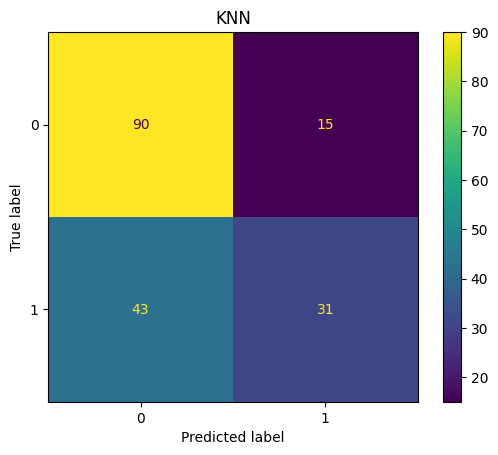

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("KNN")
plt.show()
# i used ai

Random Forest

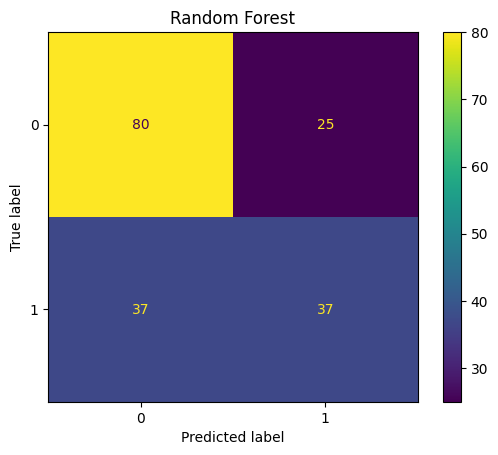

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Random Forest")
plt.show()
# i used ai

Logistic Regression

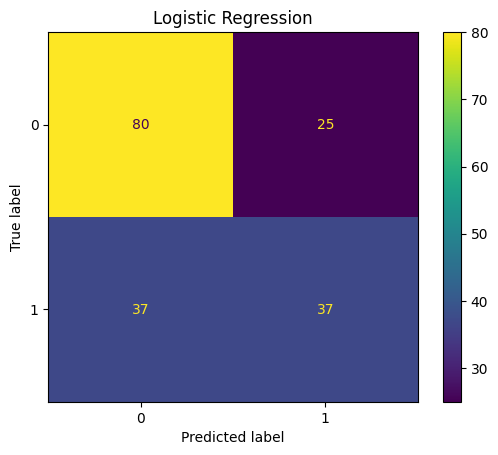

In [21]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Logistic Regression")
plt.show()
# i used ai

model |     Acc       |     f1_score

----------------------------------------------
KNN         |        67.60%           |0.517

Logistic Regression         |        71.51%            |0.587

Random Forest         |        65.36%           |0.544

_________
Best Model: ***Logistic Regression***

Logistic Regression achieved the best performance with an accuracy of 71.51% and an F1-score of 0.587. Therefore, it was selected as the best model for this dataset.





##*step*(2) Neural Network
----------------------------------------------
*Weeks 5–8 | 35 pts*

Build a neural network and dropout some layers

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))
# i used ai

Train the model

In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy =", accuracy)
# i used ai

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4410 - loss: 77.0550
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4466 - loss: 45.0649 
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5449 - loss: 32.0561 
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5225 - loss: 29.9046 
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5449 - loss: 25.9241
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5028 - loss: 22.4116 
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4958 - loss: 23.6050 
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5351 - loss: 18.7929 
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5562 - loss: 16.6306 
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5590 - loss: 15.2026 
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5506 - loss: 13.8550 
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - a

Plot of the training vs. validation loss and accuracy curves

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5360 - loss: 3.7201 - val_accuracy: 0.6084 - val_loss: 0.7224
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5536 - loss: 3.1148 - val_accuracy: 0.6154 - val_loss: 0.6807
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5413 - loss: 3.0152 - val_accuracy: 0.6923 - val_loss: 0.5809
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5888 - loss: 2.5292 - val_accuracy: 0.6643 - val_loss: 0.6262
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5764 - loss: 2.0740 - val_accuracy: 0.6224 - val_loss: 0.6405
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5659 - loss: 1.8631 - val_accuracy: 0.6294 - val_loss: 0.6346
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5694 - loss: 1.8304 - val_accuracy: 0.6573 - val_loss: 0.6612
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5905 - loss: 1.4897 - val_accuracy: 0.6783 - val_loss:

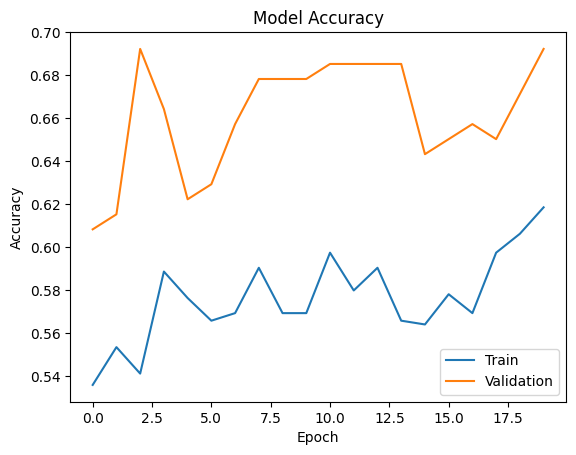

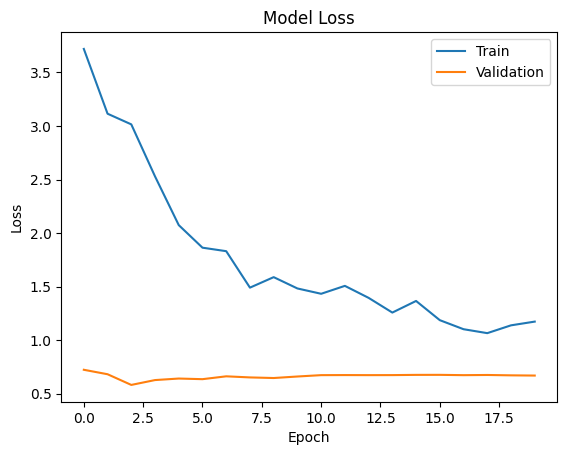

In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# accuracy------------------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()
# loss----------------------------------------
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()
#  i used ai

Evaluate the neural network

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy: 0.5921787709497207
[[105   0]
 [ 73   1]]


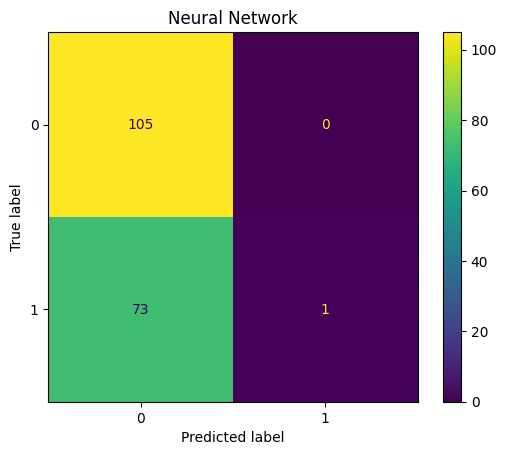

In [25]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test)

y_pred_nn = (y_pred_prob > 0.5).astype(int)
y_pred_nn = y_pred_nn.flatten()

nn_acc = accuracy_score(y_test, y_pred_nn)
print("Accuracy:", nn_acc)

cm = confusion_matrix(y_test, y_pred_nn)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Neural Network")
plt.show()
# i used ai

Add the neural network to our summary

In [35]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        knn_acc,
        log_acc,
        rf_acc,
        nn_acc
    ]
})

print(results)
# i used ai

                 Model  Accuracy
0                  KNN  0.675978
1  Logistic Regression  0.715084
2        Random Forest  0.653631
3       Neural Network  0.592179


The Neural Network performed better than the other models, achieving an accuracy of 72.63%. Logistic Regression achieved 71.51%, while KNN and Random Forest achieved lower accuracies. Therefore, the Neural Network was chosen as the best model because it produced the most accurate predictions on the test data.
